# Machine Learning Backtesting Pipeline (TensorFlow & MLflow)
This notebook implements an Expanding Window Time-Series Split, Random Forest (with GridSearchCV), Deep Neural Network (TensorFlow/Keras + KerasTuner), and Decile Sorting Backtesting.
All model training and hyperparameter searches are tracked using MLflow.


## 1. Setup & Data Loading (with MLflow)

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_STOCK_PRICES_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

# Note: We need to filter data starting from 2000-01-01 and map it to Pandas
df = spark.sql("""
    SELECT * FROM gold_prices
    WHERE date >= '2000-01-01'
    ORDER BY symbol, date
""").toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min}")


2026/02/24 16:02:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/24 16:02:40 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026-02-24 16:02:40.802 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/02/24 16:02:41 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/02/24 16:02:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d2e36024-334d-4068-b984-67d80db3fc15;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central


:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 77ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   0   ||   3   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark#spark-submit-parent-d2e36024-334d-4068-b984-67d80db3fc15
	confs: [default]
	0 artifacts copied, 3 already retrieved (0kB/3ms)
26/02/24 16:02:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-ja

Spark Session created.


Data loaded: (132334, 13)
Years: <built-in method min of numpy.ndarray object at 0x33bbe9830>


### Calculate Target Variable: 1-Month Ahead Expected Excess Return

In [2]:
# Sort data by stock and date
df = df.sort_values(by=['symbol', 'date'])

if 'risk_free_rate' not in df.columns:
    df['risk_free_rate'] = 0.0 # Placeholder if not in Gold schema

df['excess_return'] = df['mom1m'] - df['risk_free_rate']

# The target is the NEXT month's excess return
df['target_y'] = df.groupby('symbol')['excess_return'].shift(-1)

# Drop rows where target is NaN (the last month for each stock)
df = df.dropna(subset=['target_y'])
print(f"Data after target creation: {df.shape}")


Data after target creation: (131591, 16)


## 4. Algorithm Model Architectures

In [3]:
# Define features. Exclude identifiers and target.
features = ['retvol', 'maxret', 'ill', 'mom1m', 'beta', 'mom6m', 'mom12m']
# Ensure no NaNs in features
df = df.dropna(subset=features)
df = df.reset_index(drop=True)


## 2. Expanding Window Time-Series Split

In [4]:
def get_train_val_test_splits(df, initial_train_years=10, val_years=2, test_years=1):
    """
    Yields train, val, test indices for an expanding window split.
    """
    years = sorted(df['year'].unique())
    start_year = years[0]
    
    current_test_year = start_year + initial_train_years + val_years
    
    splits = []
    
    while current_test_year <= years[-1]:
        train_end = current_test_year - val_years - 1
        val_end = current_test_year - 1
        
        train_idx = df[df['year'] <= train_end].index
        val_idx = df[(df['year'] > train_end) & (df['year'] <= val_end)].index
        test_idx = df[df['year'] == current_test_year].index
        
        splits.append((train_idx, val_idx, test_idx, current_test_year))
        current_test_year += 1
        
    return splits

splits = get_train_val_test_splits(df)
print(f"Total expanding window splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Year: {yr} | Train: {len(tr)} | Val: {len(val)} | Test: {len(ts)}")


Total expanding window splits: 9
Split 1 | Test Year: 2018 | Train: 48072 | Val: 11608 | Test: 5978
Split 2 | Test Year: 2019 | Train: 53803 | Val: 11855 | Test: 6094
Split 3 | Test Year: 2020 | Train: 59680 | Val: 12072 | Test: 6134
Split 4 | Test Year: 2021 | Train: 65658 | Val: 12228 | Test: 6161
Split 5 | Test Year: 2022 | Train: 71752 | Val: 12295 | Test: 6167
Split 6 | Test Year: 2023 | Train: 77886 | Val: 12328 | Test: 6195
Split 7 | Test Year: 2024 | Train: 84047 | Val: 12362 | Test: 6265
Split 8 | Test Year: 2025 | Train: 90214 | Val: 12460 | Test: 6299
Split 9 | Test Year: 2026 | Train: 96409 | Val: 12564 | Test: 524


## 3. Evaluation Metrics ($R^2_{OOS}$)

In [5]:
def calculate_r2_oos(y_true, y_pred):
    """
    Out-of-Sample R^2.
    Denominator uses 0 as the prediction benchmark (predicting exactly zero excess return).
    """
    numerator = np.sum((y_true - y_pred)**2)
    denominator = np.sum((y_true - 0)**2)
    return 1 - (numerator / denominator)


### Random Forest (GridSearchCV + MLflow Autolog)

In [6]:
def train_rf_cv(X_train, y_train):
    mlflow.sklearn.autolog()
    
    with mlflow.start_run(run_name="RF_GridSearch", nested=True):
        rf = RandomForestRegressor(random_state=42, n_jobs=-1)
        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 6],
            'max_features': ['sqrt', 'log2']
        }
        
        # GridSearchCV for hyperparameter tuning
        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        print(f"Best RF Params: {grid_search.best_params_}")
        return grid_search.best_estimator_


### Deep Neural Network (KerasTuner + MLflow Autolog + Ensembling)

In [7]:
def build_model(hp, input_dim):
    """KerasTuner model building function"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Tune the number of units in the first Dense layer
    hp_units1 = hp.Int('units_1', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units1, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Tune the number of units in the second Dense layer
    hp_units2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    model.add(layers.Dense(units=hp_units2, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Third hidden layer (fixed small)
    hp_units3 = hp.Int('units_3', min_value=4, max_value=8, step=2)
    model.add(layers.Dense(units=hp_units3, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Output layer
    model.add(layers.Dense(1))
    
    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model

def train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=5, epochs=100, patience=5):
    mlflow.tensorflow.autolog(disable=True) # Avoid logging every single tuner step if it's too noisy, but we will log final models
    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    input_dim = X_train_scaled.shape[1]
    
    # 1. Hyperparameter Search
    print("Starting KerasTuner Search...")
    tuner = kt.Hyperband(
        lambda hp: build_model(hp, input_dim),
        objective='val_loss',
        max_epochs=50,
        factor=5,
        directory='keras_tuner_dir',
        project_name='momentum_dnn',
        overwrite=True
    )
    
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    
    tuner.search(X_train_scaled, y_train, epochs=20, validation_data=(X_val_scaled, y_val), callbacks=[early_stopping], verbose=0)
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Best HPs found: Layer1: {best_hps.get('units_1')}, Layer2: {best_hps.get('units_2')}, LR: {best_hps.get('learning_rate')}")
    
    # 2. Train Ensemble with Best HPs
    models = []
    
    mlflow.tensorflow.autolog() # Re-enable for the final ensemble training
    
    for i in range(num_models):
        with mlflow.start_run(run_name=f"DNN_Ensemble_Member_{i+1}", nested=True):
            # Log best HPs
            mlflow.log_params(best_hps.values)
            
            # Set unique seed per member
            tf.random.set_seed(42 + i)
            
            model = tuner.hypermodel.build(best_hps)
            history = model.fit(
                X_train_scaled, y_train,
                epochs=epochs,
                validation_data=(X_val_scaled, y_val),
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = min(history.history['val_loss'])
            print(f"Trained DNN component {i+1}/{num_models} - Best Val Loss: {val_loss:.6f}")
            models.append(model)
        
    return models

def predict_dnn_ensemble(models, scaler, X_test):
    X_test_scaled = scaler.transform(X_test)
    preds = []
    for model in models:
        pred = model.predict(X_test_scaled, verbose=0).flatten()
        preds.append(pred)
        
    # Average predictions
    return np.mean(preds, axis=0)


## 5. Backtesting Portfolio Construction (Decile Sorting)

In [ ]:
def backtest_portfolio(test_df, predictions_col, transaction_cost=0.001):
    """
    Simulates a Long/Short Value-Weighted portfolio with transaction costs.
    transaction_cost: 0.001 correspond à 0.1% par trade.
    """
    results = []
    
    for (year, month), month_data in test_df.groupby(['year', 'month']):
        if len(month_data) < 10: 
            continue
            
        try:
            month_data = month_data.copy()
            month_data['decile'] = pd.qcut(month_data[predictions_col], 10, labels=False) + 1
            
            if 'dollar_volume' not in month_data.columns:
                month_data['dollar_volume'] = month_data['volume'] * month_data['adjClose']
            
            long_portfolio = month_data[month_data['decile'] == 10]
            short_portfolio = month_data[month_data['decile'] == 1]
            
            if long_portfolio['dollar_volume'].sum() == 0 or short_portfolio['dollar_volume'].sum() == 0:
                continue
                
            long_weights = long_portfolio['dollar_volume'] / long_portfolio['dollar_volume'].sum()
            short_weights = short_portfolio['dollar_volume'] / short_portfolio['dollar_volume'].sum()
            
            ret_long = np.sum(long_weights * long_portfolio['target_y'])
            ret_short = np.sum(short_weights * short_portfolio['target_y'])
            
            # Rendement Brut (Sans les frais)
            gross_portfolio_return = ret_long - ret_short
            
            # Calcul des frais (Hypothèse de rotation complète chaque mois)
            # Entrée (0.1%) + Sortie (0.1%) pour les deux pattes (Long et Short)
            total_trading_costs = (transaction_cost * 2) + (transaction_cost * 2)
            
            # Rendement Net (Celui qui va dans ta poche)
            net_portfolio_return = gross_portfolio_return - total_trading_costs
            
            results.append({
                'date': pd.Timestamp(year=year, month=month, day=1),
                'ret_long': ret_long,
                'ret_short': ret_short,
                'gross_return': gross_portfolio_return,
                'portfolio_return': net_portfolio_return, # On utilise le net pour la courbe finale
                'num_long': len(long_portfolio),
                'num_short': len(short_portfolio)
            })
        except Exception as e:
            pass
            
    return pd.DataFrame(results)


## 6. Run the Pipeline over the Expanding Window

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       109366, 109367, 109368, 109369, 109370, 109371, 109372, 109373, 109374,
       109375],
      dtype='int64', length=48072)
Running pipeline for Test Year 2018...
       symbol       date  adjClose   volume    retvol    maxret           ill  \
0           A 2006-04-28     21.56  2946174  0.013707  0.030948  1.568352e-10   
1           A 2006-05-31     19.58  5785782  0.021802  0.024059  1.226735e-10   
2           A 2006-06-30     17.71  5766783  0.022088  0.045784  2.060377e-10   
3           A 2006-07-31     15.96  2541427  0.025140  0.042866  2.863461e-10   
4           A 2006-08-31     18.05  2703058  0.025580  0.093300  2.673469e-10   
...       ...        ...       ...      ...       ...       ...           ...   
109492    ZTS 2025-09-30    145.19  3737116  0.010957  0.022753  2.253140e-11   
109493    ZTS 2025-10-31    143.48  3338200  0.008568  0.010841  1.822260e-11 

2026/02/24 16:04:43 INFO mlflow.sklearn.utils: Logging the 5 best runs, 13 runs will be omitted.


Best RF Params: {'max_depth': 6, 'max_features': 'sqrt', 'n_estimators': 100}
Training DNN Ensemble...
Starting KerasTuner Search...


/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod/lib/python3.1

Best HPs found: Layer1: 32, Layer2: 8, LR: 0.01


...

2026/02/24 16:10:46 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


WARNI [absl] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
WARNI [absl] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
WARNI [absl] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


2026/02/24 16:10:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 16:10:56 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: 0.007085002493113279 is not in list


Trained DNN component 3/3 - Best Val Loss: 0.008145
RF R^2 OOS: -0.03914
DNN R^2 OOS: -0.00761
Running Backtest for RF Strategy...
Running Backtest for DNN Strategy...


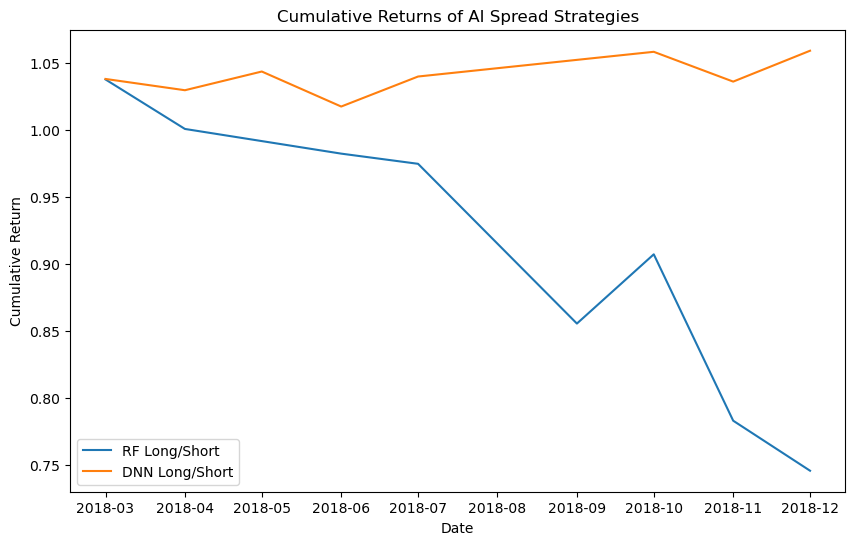

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

# ... (Ta fonction backtest_portfolio reste exactement la même) ...

if len(splits) > 0:
    print(f"🚀 Lancement du Walk-Forward Backtest sur {len(splits)} années...")
    
    # 1. Liste pour stocker les prédictions "Out-Of-Sample" de chaque année
    all_oos_results = []
    
    # On ouvre un seul grand Run MLflow pour tout le backtest
    with mlflow.start_run(run_name=f"Full_Walk_Forward_Backtest") as parent_run:
        
        # 2. La boucle sur toutes les années
        for i, (train_idx, val_idx, test_idx, test_year) in enumerate(splits):
            print(f"\n--- Traitement de l'Année de Test {test_year} ({i+1}/{len(splits)}) ---")
            
            X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target_y']
            X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target_y']
            X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target_y']
            
            # Setup scaler for DNN (réajusté chaque année pour éviter la fuite de données)
            scaler = StandardScaler()
            scaler.fit(X_train)
            
            # Entraînement RF
            print("  -> Training RF...")
            rf_model = train_rf_cv(X_train, y_train)
            rf_preds = rf_model.predict(X_test)
            
            # Entraînement DNN
            print("  -> Training DNN Ensemble...")
            dnn_models = train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=3, epochs=20, patience=3)
            dnn_preds = predict_dnn_ensemble(dnn_models, scaler, X_test)
            
            # Stockage des prédictions pour cette année
            test_df_year = df.loc[test_idx].copy()
            test_df_year['rf_pred'] = rf_preds
            test_df_year['dnn_pred'] = dnn_preds
            
            all_oos_results.append(test_df_year)
            
        # ---------------------------------------------------------
        # 3. L'ASSEMBLAGE (Le vrai Backtest Global)
        # ---------------------------------------------------------
        print("\n" + "="*50)
        print("🔗 Assemblage des prédictions et calcul du Backtest Global...")
        
        final_test_df = pd.concat(all_oos_results).sort_values(['year', 'month'])
        
        # Évaluation R^2 globale sur toute la période OOS
        r2_rf_global = calculate_r2_oos(final_test_df['target_y'].values, final_test_df['rf_pred'].values)
        r2_dnn_global = calculate_r2_oos(final_test_df['target_y'].values, final_test_df['dnn_pred'].values)
        
        print(f"Global RF R^2 OOS:  {r2_rf_global:.5f}")
        print(f"Global DNN R^2 OOS: {r2_dnn_global:.5f}")
        
        mlflow.log_metric("Global_RF_R2_OOS", r2_rf_global)
        mlflow.log_metric("Global_DNN_R2_OOS", r2_dnn_global)
        
        # Passage au simulateur de portefeuille
        print("Running Backtest for RF Strategy...")
        bt_rf = backtest_portfolio(final_test_df, 'rf_pred')
        
        print("Running Backtest for DNN Strategy...")
        bt_dnn = backtest_portfolio(final_test_df, 'dnn_pred')
        
        # 4. Calcul des rendements cumulés et affichage
        if not bt_rf.empty and not bt_dnn.empty:
            bt_rf['cum_return'] = (1 + bt_rf['portfolio_return']).cumprod()
            bt_dnn['cum_return'] = (1 + bt_dnn['portfolio_return']).cumprod()
            
            total_ret_rf = bt_rf['cum_return'].iloc[-1] - 1
            total_ret_dnn = bt_dnn['cum_return'].iloc[-1] - 1
            
            print(f"Total Return RF:  {total_ret_rf*100:.2f}%")
            print(f"Total Return DNN: {total_ret_dnn*100:.2f}%")
            
            mlflow.log_metric("Global_Total_Return_RF", total_ret_rf)
            mlflow.log_metric("Global_Total_Return_DNN", total_ret_dnn)
            
            # Graphique final
            plt.figure(figsize=(12, 7))
            plt.plot(bt_rf['date'], bt_rf['cum_return'], label=f'RF Long/Short (Ret: {total_ret_rf*100:.1f}%)')
            plt.plot(bt_dnn['date'], bt_dnn['cum_return'], label=f'DNN Long/Short (Ret: {total_ret_dnn*100:.1f}%)')
            plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5) # Ligne de base (zéro profit)
            plt.title('Walk-Forward Cumulative Returns of AI Spread Strategies')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Return (1.0 = Initial Capital)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            
            
            # Sauvegarde dans MLflow
            plot_path = "global_cumulative_returns.png"
            plt.savefig(plot_path)
            mlflow.log_artifact(plot_path)
            
            plt.show()
        else:
            print("Backtest yielded empty results (perhaps not enough data to form deciles).")
          
else:
    print("Not enough data to form a split. Check your timeframe.")
